# Proyek Klasifikasi Gambar: Red Chili Pepper Pests
- **Nama:** Bagus Alfiyan Yusuf
- **Email:** dctbagalyus@gmail.com
- **ID Dicoding:** fiyanz

## Import Semua Packages/Library yang Digunakan

In [1]:
!pip install tensorflowjs
!pip install subprocess

import os
import glob
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split

import tensorflowjs as tfjs

# Jika menggunakan Google Colab, uncomment:
# from google.colib import drive
# drive.mount('/content/drive')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

INFO: pip is looking at multiple versions of wheel to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: wheel
    Found existing installation: wheel 0.46.3
    Uninstalling wheel-0.46.3:
      Successfully uninstalled wheel-0.46.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-b

2026-05-29 16:32:29.870155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780072350.075976      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780072350.132830      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780072350.563079      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780072350.563119      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780072350.563122      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

### Data Loading

In [2]:
# Path dataset - sesuaikan dengan lokasi dataset
DATASET_DIR = "/kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset"
# Jika menggunakan Colab, ubah path berikut:
# DATASET_DIR = "/content/drive/MyDrive/RedChiliPepperPestsDataset/"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

CLASS_NAMES = ['MP (kutu daun)', 'BT (kutu kebul)', 'T (thrips)', 'C (ulat)']
NUM_CLASSES = len(CLASS_NAMES)

# Mapping prefix filename ke class_id
CLASS_MAP = {
    'kutu-daun': 0,
    'kutu-kebul': 1,
    'thrips': 2,
    'thrips-baru': 2,
    'ulat': 3,
}


def get_class_from_filename(filename):
    """
    Turunkan class_id dari prefix filename.
    Fallback: baca class_id dari file label .txt jika prefix tidak dikenal.
    """
    basename = os.path.basename(filename)
    prefix = basename.split('--')[0].lower()

    if prefix in CLASS_MAP:
        return CLASS_MAP[prefix]

    # Fallbak: baca dari file label
    label_path = filename.rsplit('.', 1)[0] + '.txt'
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            first_line = f.readline().strip()
            if first_line:
                return int(first_line.split()[0])

    raise ValueError(f"Tidak bisa menentukan kelas untuk: {filename}")


def collect_images_and_labels(image_dir):
    """Kumpulkan path gambar dan label dari sebuah direktori."""
    image_files = sorted(glob.glob(os.path.join(image_dir, '*.jpg')))
    labels = []
    valid_files = []
    for img_path in image_files:
        try:
            label = get_class_from_filename(img_path)
            labels.append(label)
            valid_files.append(img_path)
        except ValueError as e:
            print(f"Peringatan: {e}")

    return valid_files, labels


In [3]:
# Kumpulkan data dari setiap split
print("Mengumpulkan data training")
train_files, train_labels = collect_images_and_labels(
    os.path.join(DATASET_DIR, 'train', 'images')
)
print(f"Training: {len(train_files)} gambar")

Mengumpulkan data training
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/train/images/IMG_20211201_100935_jpg.rf.3f0be597263fe7912269fa2a3c5a0864.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/train/images/IMG_20211201_100935_jpg.rf.915935720b7337fb0e2983ae2e2fef36.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/train/images/IMG_20211201_100935_jpg.rf.de198104ff310a2f808780d9a1c972a5.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/train/images/IMG_20211201_101052_jpg.rf.10764a17e9959b390cd2cfdef7091939.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/train/images/IMG_20211201_101052_jpg.rf.5dbaa210295f764bebf7f495e217fab4.jpg
Peringatan: T

In [4]:
print("Mengumpulkan data validasi")
val_files_1, val_labels_1 = collect_images_and_labels(
    os.path.join(DATASET_DIR, 'val', 'images')
)
val_files_2, val_labels_2 = collect_images_and_labels(
    os.path.join(DATASET_DIR, 'val', 'valid', 'images')
)
val_files = val_files_1 + val_files_2
val_labels = val_labels_1 + val_labels_2
print(f"Validasi: {len(val_files)} gabungan ({len(val_files_1)} + {len(val_files_2)})")

Mengumpulkan data validasi
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/val/images/kutu-daun_jpg.rf.821383e925566501f287df3ba51db64a.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/val/valid/images/kutu-daun_jpg.rf.821383e925566501f287df3ba51db64a.jpg
Validasi: 1996 gabungan (998 + 998)


In [5]:
print("Mengumpulkan data test")
test_files, test_labels = collect_images_and_labels(
    os.path.join(DATASET_DIR, 'test', 'images')
)
print(f"Test: {len(test_files)} gambar")

# Distribusi kelas
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\nDistribusi {split_name}:")
    for cls_id, count in zip(unique, counts):
        print(f"  {CLASS_NAMES[cls_id]}: {count} ({count/len(labels)*100:.1f}%)")

Mengumpulkan data test
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/test/images/IMG_20211201_102102_jpg.rf.721f9d94c67c2e6706d803d3823a5bf4.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/test/images/IMG_20211204_141621_jpg.rf.86c1f315ac3fb92a79d40c5585a2dec2.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/test/images/IMG_20211204_142657_jpg.rf.079465ac5c65530d54af29d6d3d1570f.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/test/images/IMG_20211204_143233_jpg.rf.24ef53483039b1f89d3956a5a6d1ce46.jpg
Peringatan: Tidak bisa menentukan kelas untuk: /kaggle/input/datasets/indraagustian/red-chili-pepper-pests-dataset/test/images/IMG_20211204_160803_jpg.rf.93d56f4b9b3bc026a0d3099930d4d1e8.jpg
Peringatan: Tidak bisa

### Data Preprocessing

#### Split Dataset

In [6]:
# Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
], name="data_augmentation")


def parse_image(file_path, label):
    """Baca, decode, dan normalisasi gambar."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label


def augment_image(image, label):
    """Terapkan data augmentation pada gambar."""
    image = data_augmentation(image)
    return image, label


def create_dataset(file_paths, labels, batch_size=BATCH_SIZE, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=42)
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size) 
    if augment:
        ds = ds.map(augment_image, num_parallel_calls=AUTOTUNE)  # then augment
    ds = ds.prefetch(AUTOTUNE)
    return ds


I0000 00:00:1780072377.079674      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
# Buat dataset untuk setiap split
train_ds = create_dataset(train_files, train_labels, shuffle=True, augment=True)
val_ds = create_dataset(val_files, val_labels, shuffle=False, augment=False)
test_ds = create_dataset(test_files, test_labels, shuffle=False, augment=False)

all_train_files  = train_files + val_files
all_train_labels = train_labels + val_labels

train_files, val_files, train_labels, val_labels = train_test_split(
    all_train_files,
    all_train_labels,
    test_size=0.15,
    stratify=all_train_labels,
    random_state=42
)

print(f"Train : {len(train_files)} gambar")
print(f"Val   : {len(val_files)} gambar")
print(f"Test  : {len(test_files)} gambar")

Train : 4522 gambar
Val   : 799 gambar
Test  : 490 gambar


In [8]:
# Hitung class weights untuk menangani ketidakseimbangan kelas
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2, 3]),
    y=np.array(train_labels)
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights:")
for i, w in class_weight_dict.items():
    print(f"  {CLASS_NAMES[i]}: weight={w:.4f}")


Class weights:
  MP (kutu daun): weight=2.0116
  BT (kutu kebul): weight=0.8909
  T (thrips): weight=1.4875
  C (ulat): weight=0.5854


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0013798475..1.0445035].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.043196082..1.0644763].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0354118].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00031280518..1.0611081].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0791639].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0490243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1251318].
Clippin

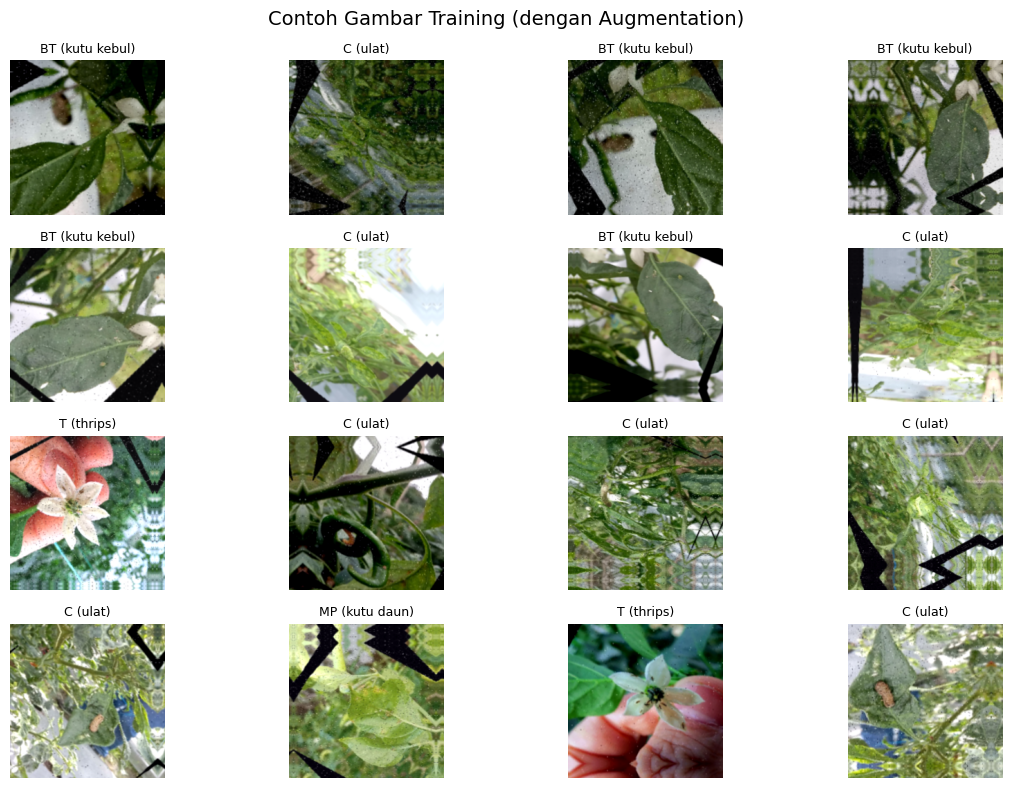

In [9]:
# Visualisasi contoh gambar training
plt.figure(figsize=(12, 8))
sample_images, sample_labels = next(iter(train_ds))
for i in range(min(16, len(sample_images))):
    plt.subplot(4, 4, i + 1)
    plt.imshow(sample_images[i])
    label_idx = tf.argmax(sample_labels[i]).numpy()
    plt.title(CLASS_NAMES[label_idx], fontsize=9)
    plt.axis('off')
plt.suptitle('Contoh Gambar Training (dengan Augmentation)', fontsize=14)
plt.tight_layout()
plt.show()

## Modelling

In [10]:
def build_cnn_model(input_shape=(224, 224, 3), num_classes=4):
    inputs = keras.Input(shape=input_shape, name='input_image')

    # Block 1: 32 filters
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 2: 64 filters
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 3: 128 filters
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)

    # Block 4: 256 filters
    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.4)(x)

    # Classifier Head — lebih sederhana untuk kurangi overfitting
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return keras.Model(inputs, outputs, name='pest_classifier_cnn')

model = build_cnn_model(input_shape=(*IMAGE_SIZE, 3), num_classes=NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

Model: "pest_classifier_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,242,724 (4.74 MB)

 Trainable params: 1,240,292 (4.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [11]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.3,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]


In [12]:
# Training
EPOCHS = 100

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100


I0000 00:00:1780072388.630588     143 service.cc:152] XLA service 0x795e5809c680 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780072388.630649     143 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780072389.937984     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/104 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.3438 - loss: 1.8980  

I0000 00:00:1780072404.508134     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.5284 - loss: 1.1819
Epoch 1: val_accuracy improved from -inf to 0.23848, saving model to best_model.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 81s 578ms/step - accuracy: 0.5296 - loss: 1.1797 - val_accuracy: 0.2385 - val_loss: 2.6419 - learning_rate: 3.0000e-04
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.8433 - loss: 0.6813
Epoch 2: val_accuracy did not improve from 0.23848
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 355ms/step - accuracy: 0.8434 - loss: 0.6813 - val_accuracy: 0.2385 - val_loss: 7.4441 - learning_rate: 3.0000e-04
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.8788 - loss: 0.6086
Epoch 3: val_accuracy did not improve from 0.23848
104/104 ━━━━━━━━━━━━━━━━━━━━ 38s 354ms/step - accuracy: 0.8790 - loss: 0.6084 - val_accuracy: 0.2385 - val_loss: 9.0479 - learning_rate: 3.0000e-04
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.9307 - loss: 0.5111
Epoch 4: val_accuracy im

## Evaluasi dan Visualisasi

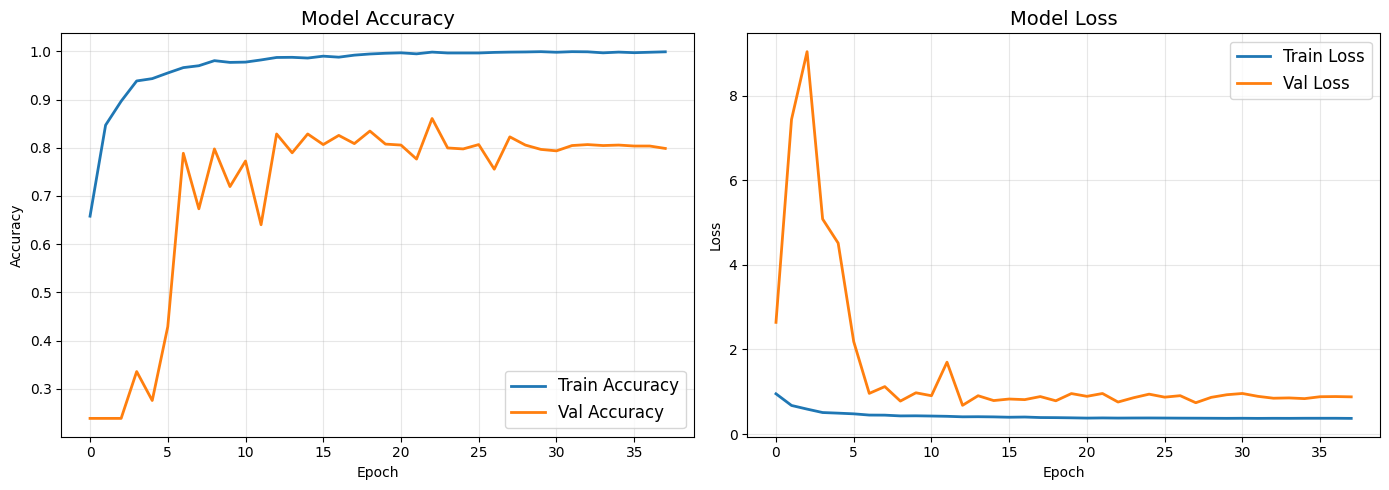


Final Train Accuracy: 0.9991
Final Val Accuracy: 0.7986
Best Val Accuracy: 0.8607


In [13]:
def plot_training_history(history):
    """Plot kurva accuracy dan loss selama training."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    ax1.set_title('Model Accuracy', fontsize=14)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title('Model Loss', fontsize=14)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_training_history(history)

print(f"\nFinal Train Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best Val Accuracy: {max(history.history['val_accuracy']):.4f}")

Evaluasi pada Test Set

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 216ms/step
Classification Report
                 precision    recall  f1-score   support

 MP (kutu daun)     1.0000    0.9219    0.9593        64
BT (kutu kebul)     0.8457    1.0000    0.9164       159
     T (thrips)     1.0000    0.9565    0.9778        46
       C (ulat)     0.9950    0.8959    0.9429       221

       accuracy                         0.9388       490
      macro avg     0.9602    0.9436    0.9491       490
   weighted avg     0.9477    0.9388    0.9397       490



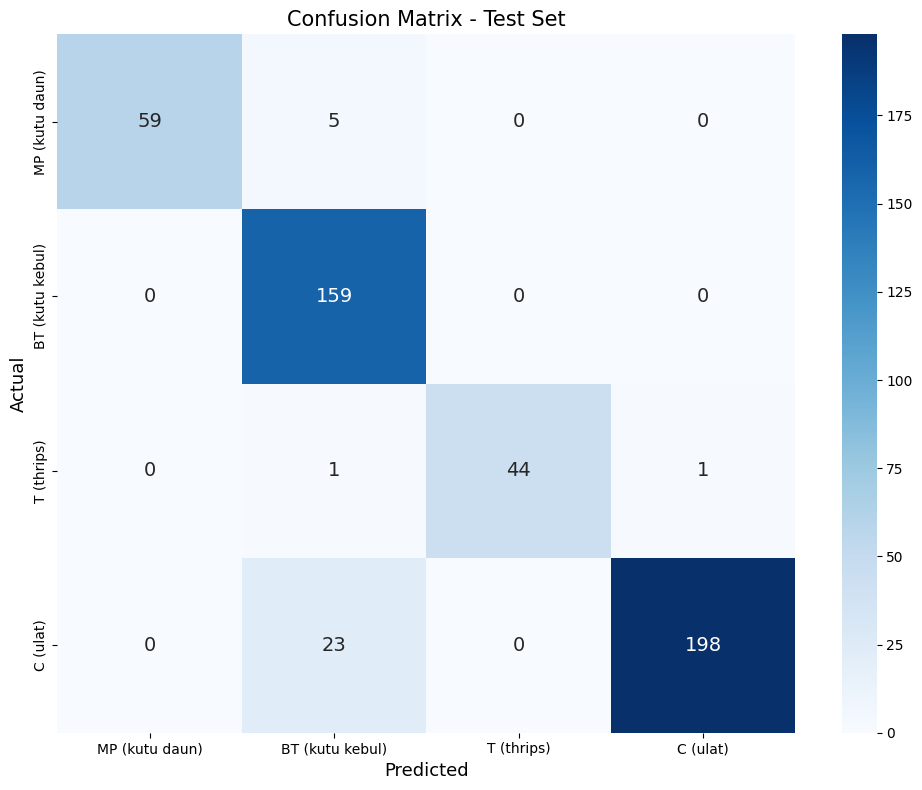


Test Accuracy: 0.9388 (460/490)


In [14]:
# Evaluasi pada test set
print("Evaluasi pada Test Set\n")

# Load best model
best_model = keras.models.load_model('best_model.keras')

# Prediksi
y_pred_probs = best_model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels)

# Classification Report
print("Classification Report")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={"size": 14})
plt.xlabel('Predicted', fontsize=13)
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix - Test Set', fontsize=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

test_accuracy = np.sum(y_pred == y_true) / len(y_true)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({np.sum(y_pred == y_true)}/{len(y_true)})")

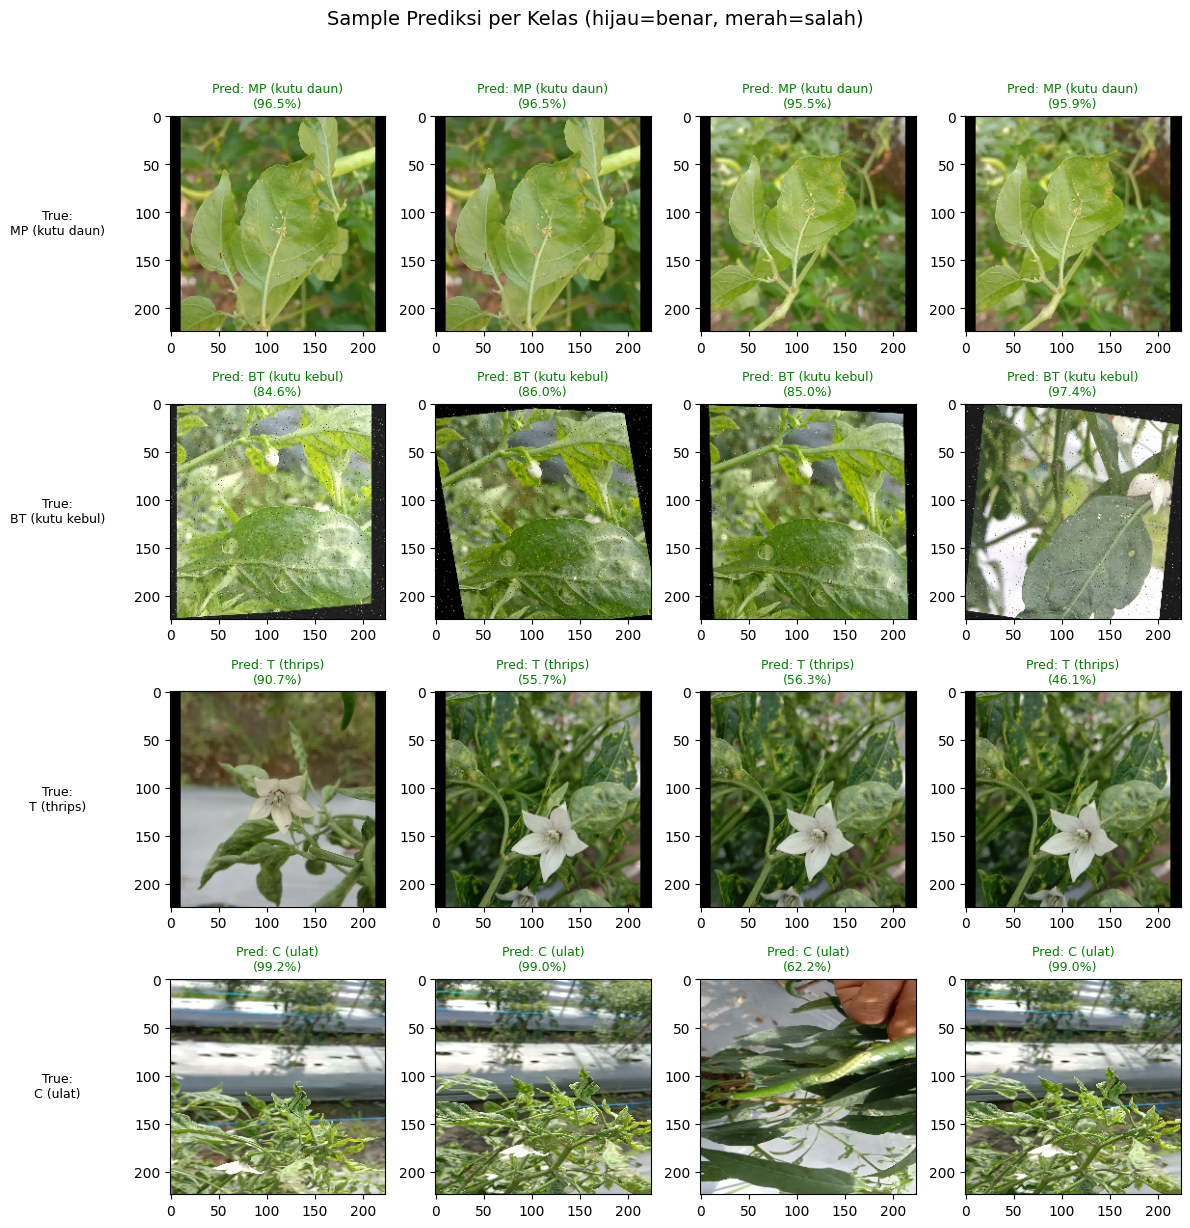

In [15]:
def show_sample_predictions(ds, class_names, n_per_class=4):
    """Tampilkan sample prediksi dengan minimal n sampel per kelas."""
    num_classes = len(class_names)
    
    # Kumpulkan sampel per kelas
    class_images = {i: [] for i in range(num_classes)}
    class_labels = {i: [] for i in range(num_classes)}
    class_preds  = {i: [] for i in range(num_classes)}

    for images, labels in ds:
        preds = best_model.predict(images, verbose=0)
        for i in range(len(images)):
            true_idx = tf.argmax(labels[i]).numpy()
            if len(class_images[true_idx]) < n_per_class:
                class_images[true_idx].append(images[i].numpy())
                class_labels[true_idx].append(true_idx)
                class_preds[true_idx].append(preds[i])
        # Stop kalau semua kelas sudah terpenuhi
        if all(len(v) >= n_per_class for v in class_images.values()):
            break

    # Plot: baris = kelas, kolom = sampel
    fig, axes = plt.subplots(num_classes, n_per_class, figsize=(n_per_class * 3, num_classes * 3))
    
    for row, class_idx in enumerate(range(num_classes)):
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(class_images[class_idx]):
                img   = class_images[class_idx][col]
                pred  = class_preds[class_idx][col]
                pred_idx    = np.argmax(pred)
                confidence  = np.max(pred) * 100
                true_label  = class_names[class_idx]
                pred_label  = class_names[pred_idx]
                color = 'green' if true_label == pred_label else 'red'
                ax.imshow(img)
                ax.set_title(
                    f"Pred: {pred_label}\n({confidence:.1f}%)",
                    color=color, fontsize=9
                )
                # Label baris di kolom pertama
                if col == 0:
                    ax.set_ylabel(
                        f"True:\n{true_label}",
                        fontsize=9, rotation=0,
                        labelpad=55, va='center'
                    )
            else:
                ax.axis('off')
                ax.set_xticks([])
                ax.set_yticks([])

    plt.suptitle('Sample Prediksi per Kelas (hijau=benar, merah=salah)',fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_predictions(test_ds, CLASS_NAMES, n_per_class=4)

## Konversi Model

In [16]:
# Load model terbaik
best_model = keras.models.load_model('best_model.keras')

# Simpan ke SavedModel (.pb)
best_model.export('saved_model/pest_classifier')

print("SavedModel (.pb) tersimpan di: saved_model/pest_classifier/")


INFO:tensorflow:Assets written to: saved_model/pest_classifier/assets


INFO:tensorflow:Assets written to: saved_model/pest_classifier/assets


Saved artifact at 'saved_model/pest_classifier'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')]
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133447592287824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592280144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592285520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592284944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592283984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592285136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592286480: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [17]:
# Konversi ke TFLite (float32)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

tflite_path = 'model_pest_classification.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"TFLite model (float32): {tflite_path}")
print(f"Ukuran: {len(tflite_model) / 1024 / 1024:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpmpf6fwgn/assets


INFO:tensorflow:Assets written to: /tmp/tmpmpf6fwgn/assets


Saved artifact at '/tmp/tmpmpf6fwgn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133447592287824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592280144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592285520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592284944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592283984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592285136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592286480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592284560

W0000 00:00:1780073871.913663      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780073871.913720      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780073871.946868      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


In [18]:
# Konversi ke TFLite Quantized (float16)
converter_quant = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter_quant.optimizations = [tf.lite.Optimize.DEFAULT]
converter_quant.target_spec.supported_types = [tf.float16]
tflite_quant_model = converter_quant.convert()

tflite_quant_path = 'model_pest_classification_quantized.tflite'
with open(tflite_quant_path, 'wb') as f:
    f.write(tflite_quant_model)
print(f"TFLite model (quantized float16): {tflite_quant_path}")
print(f"Ukuran: {len(tflite_quant_model) / 1024 / 1024:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpwzkrabt0/assets


INFO:tensorflow:Assets written to: /tmp/tmpwzkrabt0/assets


Saved artifact at '/tmp/tmpwzkrabt0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133447592287824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592280144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592285520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592284944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592283984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592285136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592286480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592284560

W0000 00:00:1780073873.908797      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780073873.908823      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [19]:
# convert model ke pb format
best_model.export('save_model')

INFO:tensorflow:Assets written to: save_model/assets


INFO:tensorflow:Assets written to: save_model/assets


Saved artifact at 'save_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')]
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133447592287824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592280144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592285520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592284944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592283984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592287440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592285136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592286480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133447592284560

In [20]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    /kaggle/working/saved_model/pest_classifier \
    /kaggle/working/tfjs_model

2026-05-29 16:57:56.136573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780073876.159804    1385 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780073876.167521    1385 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780073876.186020    1385 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780073876.186066    1385 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780073876.186073    1385 computation_placer.cc:177] computation placer alr

In [21]:
# Simpan juga format Keras
best_model.save('model_pest_classification.keras')
print(f"Keras model: model_pest_classification.keras")

Keras model: model_pest_classification.keras


## Inference (Optional)

In [22]:
CLASS_NAMES_SHORT = ['MP (kutu daun/aphid)', 'BT (kutu kebul/whitefly)',
                     'T (thrips)', 'C (ulat/caterpillar)']


def predict_pest(image_path, model_path='best_model.keras'):
    """
    Klasifikasi satu gambar hama.

    Args:
        image_path: Path ke file gambar JPEG.
        model_path: Path ke model Keras yang disimpan.

    Returns:
        Dictionary dengan prediksi dan probabilitas.
    """
    model_inf = keras.models.load_model(model_path)

    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, 0)

    probs = model_inf.predict(img, verbose=0)[0]
    predicted_class = np.argmax(probs)

    return {
        'predicted_class_id': int(predicted_class),
        'predicted_class_name': CLASS_NAMES_SHORT[predicted_class],
        'confidence': float(probs[predicted_class]),
        'all_probabilities': {
            CLASS_NAMES_SHORT[i]: float(probs[i]) for i in range(NUM_CLASSES)
        }
    }


def predict_pest_tflite(image_path, tflite_path='model_pest_classification.tflite'):
    """Inference menggunakan model TFLite."""
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, 0).numpy()

    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    probs = interpreter.get_tensor(output_details[0]['index'])[0]

    predicted_class = np.argmax(probs)
    return {
        'predicted_class_id': int(predicted_class),
        'predicted_class_name': CLASS_NAMES_SHORT[predicted_class],
        'confidence': float(probs[predicted_class]),
        'all_probabilities': {
            CLASS_NAMES_SHORT[i]: float(probs[i]) for i in range(NUM_CLASSES)
        }
    }


In [23]:
# Test inference pada beberapa gambar dari test set
print("Test Inference (Keras Model)\n")

sample_test_files = random.sample(test_files, min(5, len(test_files)))
for img_path in sample_test_files:
    result = predict_pest(img_path)
    true_label = CLASS_NAMES_SHORT[test_labels[test_files.index(img_path)]]
    correct = "Yes" if result['predicted_class_name'] == true_label else "No"
    print(f"{correct} {os.path.basename(img_path)}:")
    print(f"   True: {true_label}")
    print(f"   Pred: {result['predicted_class_name']} (conf: {result['confidence']:.2%})")
    probs_str = ', '.join([f"{name}: {prob:.2%}" for name, prob in result['all_probabilities'].items()])
    print(f"   Probs: {probs_str}")
    print()

Test Inference (Keras Model)

Yes thrips--376-_jpg.rf.7879ce765cb07a5330e96d6772a232c5.jpg:
   True: T (thrips)
   Pred: T (thrips) (conf: 66.73%)
   Probs: MP (kutu daun/aphid): 4.89%, BT (kutu kebul/whitefly): 21.47%, T (thrips): 66.73%, C (ulat/caterpillar): 6.91%

Yes kutu-kebul--491-_jpg.rf.160f4cbe28721601597d1e9dea240581.jpg:
   True: BT (kutu kebul/whitefly)
   Pred: BT (kutu kebul/whitefly) (conf: 98.58%)
   Probs: MP (kutu daun/aphid): 0.70%, BT (kutu kebul/whitefly): 98.58%, T (thrips): 0.57%, C (ulat/caterpillar): 0.15%

Yes thrips--156-_jpg.rf.d29bb27744a9ea216b2eb5fcbede398b.jpg:
   True: T (thrips)
   Pred: T (thrips) (conf: 92.70%)
   Probs: MP (kutu daun/aphid): 2.87%, BT (kutu kebul/whitefly): 2.97%, T (thrips): 92.70%, C (ulat/caterpillar): 1.46%



Yes kutu-kebul--374-_jpg.rf.4f1aed735b989731fdf6795d6f6046c0.jpg:
   True: BT (kutu kebul/whitefly)
   Pred: BT (kutu kebul/whitefly) (conf: 95.88%)
   Probs: MP (kutu daun/aphid): 0.99%, BT (kutu kebul/whitefly): 95.88%, T (thrips): 0.38%, C (ulat/caterpillar): 2.74%



Yes thrips--429-_jpg.rf.123573ea1056102b66aa9ebbd69b6a18.jpg:
   True: T (thrips)
   Pred: T (thrips) (conf: 94.38%)
   Probs: MP (kutu daun/aphid): 1.53%, BT (kutu kebul/whitefly): 2.05%, T (thrips): 94.38%, C (ulat/caterpillar): 2.04%



In [24]:
print("Test Inference (SavedModel .pb)\n")

# Load SavedModel
pb_model = tf.saved_model.load('saved_model/pest_classifier')
infer = pb_model.signatures['serving_default']

sample_test_files = random.sample(test_files, min(5, len(test_files)))
for img_path in sample_test_files:
    # Preprocess
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.expand_dims(img, axis=0)

    # Inference
    output = infer(img)
    probs = list(output.values())[0].numpy()[0]

    pred_idx = np.argmax(probs)
    pred_name = CLASS_NAMES_SHORT[pred_idx]
    confidence = probs[pred_idx]
    true_label = CLASS_NAMES_SHORT[test_labels[test_files.index(img_path)]]
    correct = "Yes" if pred_name == true_label else "No"

    print(f"{correct} {os.path.basename(img_path)}:")
    print(f"   True: {true_label}")
    print(f"   Pred: {pred_name} (conf: {confidence:.2%})")
    probs_str = ', '.join([f"{CLASS_NAMES_SHORT[i]}: {p:.2%}" for i, p in enumerate(probs)])
    print(f"   Probs: {probs_str}")
    print()

Test Inference (SavedModel .pb)

Yes kutu-kebul--529-_jpg.rf.c2af299ef2120413995b706332624897.jpg:
   True: BT (kutu kebul/whitefly)
   Pred: BT (kutu kebul/whitefly) (conf: 99.37%)
   Probs: MP (kutu daun/aphid): 0.34%, BT (kutu kebul/whitefly): 99.37%, T (thrips): 0.11%, C (ulat/caterpillar): 0.18%

Yes kutu-kebul--480-_jpg.rf.9258a3b431d745d392af503cbd537c8a.jpg:
   True: BT (kutu kebul/whitefly)
   Pred: BT (kutu kebul/whitefly) (conf: 99.49%)
   Probs: MP (kutu daun/aphid): 0.25%, BT (kutu kebul/whitefly): 99.49%, T (thrips): 0.17%, C (ulat/caterpillar): 0.09%

Yes kutu-kebul--378-_jpg.rf.b181f8ae982584cb7bd776c397078124.jpg:
   True: BT (kutu kebul/whitefly)
   Pred: BT (kutu kebul/whitefly) (conf: 99.10%)
   Probs: MP (kutu daun/aphid): 0.38%, BT (kutu kebul/whitefly): 99.10%, T (thrips): 0.40%, C (ulat/caterpillar): 0.12%

Yes kutu-daun--278-_jpg.rf.227744a27febe735c4d9d38e8f869ccc.jpg:
   True: MP (kutu daun/aphid)
   Pred: MP (kutu daun/aphid) (conf: 94.59%)
   Probs: MP (kut

In [25]:
# Test inference TFLite
print("Test Inference (TFLite Model)\n")

for img_path in sample_test_files[:3]:
    result = predict_pest_tflite(img_path)
    true_label = CLASS_NAMES_SHORT[test_labels[test_files.index(img_path)]]
    correct = "Yes" if result['predicted_class_name'] == true_label else "No"
    print(f"{correct} {os.path.basename(img_path)}:")
    print(f"   True: {true_label}")
    print(f"   Pred: {result['predicted_class_name']} (conf: {result['confidence']:.2%})")
    print()

Test Inference (TFLite Model)

Yes kutu-kebul--529-_jpg.rf.c2af299ef2120413995b706332624897.jpg:
   True: BT (kutu kebul/whitefly)
   Pred: BT (kutu kebul/whitefly) (conf: 99.37%)

Yes kutu-kebul--480-_jpg.rf.9258a3b431d745d392af503cbd537c8a.jpg:
   True: BT (kutu kebul/whitefly)
   Pred: BT (kutu kebul/whitefly) (conf: 99.49%)



/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Yes kutu-kebul--378-_jpg.rf.b181f8ae982584cb7bd776c397078124.jpg:
   True: BT (kutu kebul/whitefly)
   Pred: BT (kutu kebul/whitefly) (conf: 99.10%)

